# AlphaGenome Gene Expression Predictions — Evaluation

This notebook evaluates [AlphaGenome](https://github.com/google-deepmind/alphagenome) (AG) predicted gene expression values against experimental measurements from a human–chimpanzee hybrid study.

Predicted log₂ fold changes (LFC, human / chimp) and absolute expression levels (TPM) are compared to experimental allele-specific measurements from the hybrid dataset.

## 1. Setup

Import required libraries.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import config
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import gaussian_kde

## 2. Load AlphaGenome Predictions

Scan all `.tsv` files in `./data/AG_gene_predicitons/` using Polars lazy evaluation and collect into a single DataFrame.  
Each row corresponds to one gene with predicted human and chimp expression values (`HumanGeneExpression`, `ChimpGeneExpression`) and a predicted log₂ fold change (`LFC`).

In [7]:

mpra_seq_with_embedding = pl.scan_csv(
    "./results/all_genes/*.tsv", separator="\t"
)

df = mpra_seq_with_embedding.collect()

## 3. Predicted LFC Distribution

Visualise the distribution of AlphaGenome-predicted log₂ fold changes (human / chimp) across all genes.  
Dashed and dotted vertical lines mark the mean and median, respectively.  
The hybrid experimental data (`hybrids`) is also loaded at the end of this cell for use in subsequent sections.

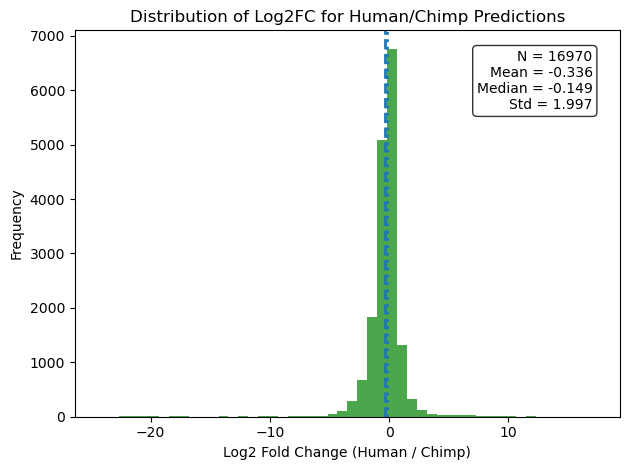

In [8]:


lfc = df['LFC'].drop_nulls().to_numpy()

mean = np.mean(lfc)
median = np.median(lfc)
std = np.std(lfc)
n = len(lfc)

plt.hist(lfc, bins=50, color='green', alpha=0.7)

plt.axvline(mean, linestyle='dashed', linewidth=2)
plt.axvline(median, linestyle='dotted', linewidth=2)

plt.xlabel('Log2 Fold Change (Human / Chimp)')
plt.ylabel('Frequency')
plt.title('Distribution of Log2FC for Human/Chimp Predictions')

stats_text = (
    f'N = {n}\n'
    f'Mean = {mean:.3f}\n'
    f'Median = {median:.3f}\n'
    f'Std = {std:.3f}'
)

plt.text(
    0.95, 0.95,
    stats_text,
    transform=plt.gca().transAxes,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.tight_layout()
plt.show()
hybrids =pl.read_csv (config.HUMAN_CHIMP_HYBRIDS_DATA_PATH_WEXAC, separator="\t")

## 4. Join Predictions with Hybrid Experimental Data

Inner-join the AG predictions with the hybrid dataset on gene symbol (`HumanGeneSymbol` ↔ `Gene`),  
retaining only genes present in both sources.

In [12]:
df.head()

GeneSymbol,HumanGeneID,ChimpGeneID,LFC,HumanGeneExpression,ChimpGeneExpression
str,i64,i64,f64,f64,f64
"""SAMD11""",148398,100608581,5.605576,0.302199,0.006206
"""NOC2L""",26155,100608665,5.298696,1.664787,0.042295
"""KLHL17""",339451,465388,13.25118,0.33285,0.000034
"""PLEKHN1""",84069,100608864,10.237682,0.031878,0.000026
"""PERM1""",84808,100609047,-4.686088,0.001225,0.031547


In [13]:
ag_preds_with_hybrids = df.join(hybrids, left_on="GeneSymbol", right_on="Gene", how="inner")

### 4.1 Note: Attempted Pre-computation of Log-transformed Columns

The commented-out code below was an attempt to pre-compute log₁₀-transformed and mean-normalised expression columns directly in the DataFrame.  
The approach was abandoned due to a Polars operator-precedence issue where `.alias()` bound to the wrong sub-expression.  
The same transformations are applied inline during plotting in the sections below.

In [5]:
##  I wanted to create the plotted clumns instead of calculate it only for the plot, for some reason it failed.

# ag_preds_with_hybrids = ag_preds_with_hybrids.with_columns(((1 + pl.col('ExpLBM_TPM_human_allele')).log10()).alias('hybrids_log10ExpLBM_TPM_human_allele')) 
# ag_preds_with_hybrids = ag_preds_with_hybrids.with_columns(((1+ pl.col('ExpLBM_TPM_chimp_allele')).log10()).alias('hybrids_log10ExpLBM_TPM_chimp_allele'))
# ag_preds_with_hybrids = ag_preds_with_hybrids.with_columns((pl.col('hybrids_log10ExpLBM_TPM_human_allele')/pl.col('hybrids_log10ExpLBM_TPM_chimp_allele')).alias('hybrids_log10_TPM_ratio'))
# ag_preds_with_hybrids = ag_preds_with_hybrids.with_columns(((1 + pl.col('HumanGeneExpression')).log10()).alias('pred_Log10HumanGeneExpression'))
# ag_preds_with_hybrids = ag_preds_with_hybrids.with_columns(((1 + pl.col('ChimpGeneExpression')).log10()).alias('pred_Log10ChimpGeneExpression'))
# ag_preds_with_hybrids = ag_preds_with_hybrids.with_columns(pl.col('pred_Log10HumanGeneExpression')/pl.col('pred_Log10ChimpGeneExpression').alias('pred_Log10ExpressionRatio'))
# ag_preds_with_hybrids = ag_preds_with_hybrids.with_columns((pl.col('pred_Log10HumanGeneExpression') - pl.col('pred_Log10HumanGeneExpression').mean()).alias('pred_normalized_HumanGeneExpression'))
# ag_preds_with_hybrids = ag_preds_with_hybrids.with_columns((pl.col('pred_Log10ChimpGeneExpression') - pl.col('pred_Log10ChimpGeneExpression').mean()).alias('pred_normalized_ChimpGeneExpression'))
# ag_preds_with_hybrids = ag_preds_with_hybrids.with_columns((pl.col('hybrids_log10ExpLBM_TPM_human_allele') - pl.col('hybrids_log10ExpLBM_TPM_human_allele').mean()).alias('hybrids_normalized_HumanGeneExpression'))
# ag_preds_with_hybrids = ag_preds_with_hybrids.with_columns((pl.col('hybrids_log10ExpLBM_TPM_chimp_allele') - pl.col('hybrids_log10ExpLBM_TPM_chimp_allele').mean()).alias('hybrids_normalized_ChimpGeneExpression'))

## 5. LFC Correlation: Predicted vs. Experimental

Compare AlphaGenome-predicted LFC with the experimental LFC from the hybrid dataset (`ExpLBM_LFC_human_ref`).  
Finite values only are retained; points are coloured by local kernel-density estimate (KDE).

### 5.1 Linear Scale — Ordinary Least-Squares Regression Line

Raw LFC values on both axes; the blue line shows the OLS regression fit.

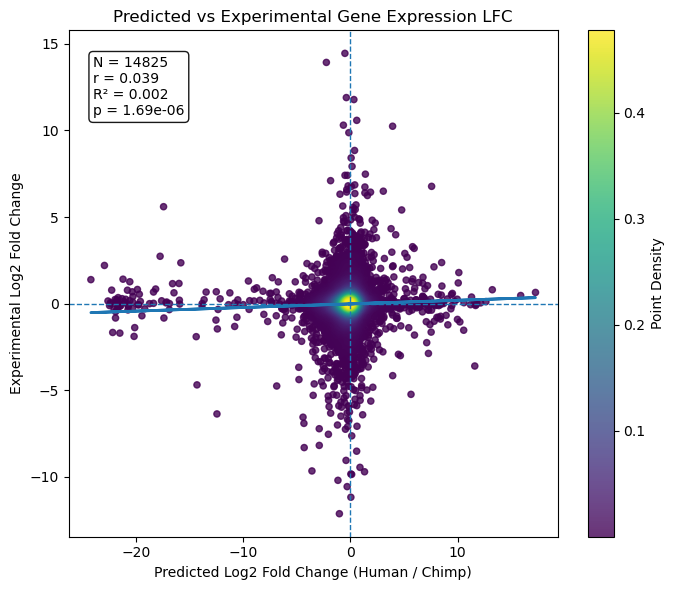

In [6]:


# Drop NaNs
x = ag_preds_with_hybrids['LFC'].to_numpy()
y = ag_preds_with_hybrids['ExpLBM_LFC_human_ref'].to_numpy()

mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

# Density estimation
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# Sort by density so high density points plot on top
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]

# Correlation
r, p = pearsonr(x, y)
r2 = r**2

# Plot
plt.figure(figsize=(7,6))

sc = plt.scatter(
    x, y,
    c=z,
    cmap='viridis',
    s=20,
    alpha=0.8
)

# Regression line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, linewidth=2)

plt.xlabel('Predicted Log2 Fold Change (Human / Chimp)')
plt.ylabel('Experimental Log2 Fold Change')
plt.title('Predicted vs Experimental Gene Expression LFC')

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Point Density')

# Stats box
stats_text = (
    f'N = {len(x)}\n'
    f'r = {r:.3f}\n'
    f'R² = {r2:.3f}\n'
    f'p = {p:.2e}'
)

plt.text(
    0.05, 0.95,
    stats_text,
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9)
)

plt.axhline(0, linestyle='--', linewidth=1)
plt.axvline(0, linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

### 5.2 Log₁₀ Scale — Mean-Centred, Identity Line

Both axes are log₁₀-transformed and mean-centred before plotting.  
The red dashed identity line (x = y) indicates perfect prediction; deviation from it reflects systematic bias.

/tmp/ipykernel_2809477/1332698437.py:2: RuntimeWarning: invalid value encountered in log10
  x= np.log10(ag_preds_with_hybrids['ExpLBM_LFC_human_ref'].to_numpy())
/tmp/ipykernel_2809477/1332698437.py:3: RuntimeWarning: divide by zero encountered in log10
  y = np.log10(ag_preds_with_hybrids['LFC'].to_numpy())
/tmp/ipykernel_2809477/1332698437.py:3: RuntimeWarning: invalid value encountered in log10
  y = np.log10(ag_preds_with_hybrids['LFC'].to_numpy())


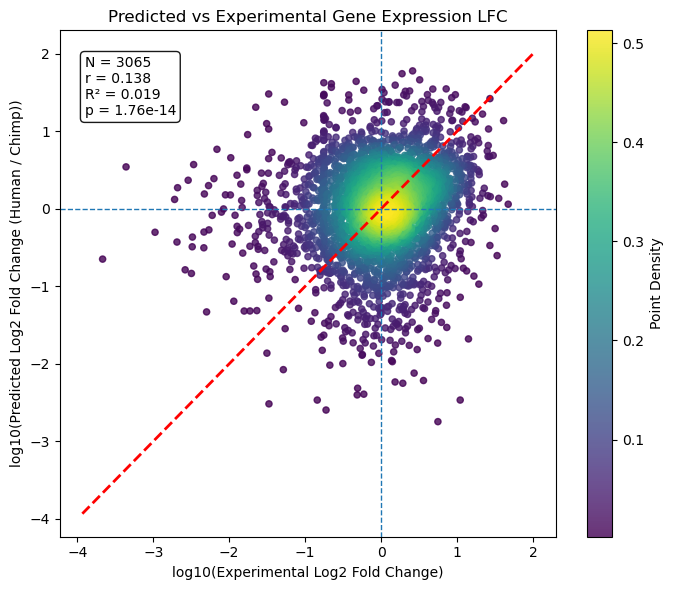

In [7]:


# Drop NaNs
x= np.log10(ag_preds_with_hybrids['ExpLBM_LFC_human_ref'].to_numpy())
y = np.log10(ag_preds_with_hybrids['LFC'].to_numpy())

mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

#normalization
x = x - np.mean(x)
y = y - np.mean(y)
# Density estimation
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# Sort by density so high density points plot on top
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]

# Correlation
r, p = pearsonr(x, y)
r2 = r**2

# Plot
plt.figure(figsize=(7,6))

sc = plt.scatter(
    x, y,
    c=z,
    cmap='viridis',
    s=20,
    alpha=0.8
)
# Add x = y line
lims = [
    np.min([plt.gca().get_xlim(), plt.gca().get_ylim()]),
    np.max([plt.gca().get_xlim(), plt.gca().get_ylim()]),
]
plt.plot(lims, lims, linestyle='--', linewidth=2, color='red', label='x = y')

# # Regression line
# m, b = np.polyfit(x, y, 1)
# plt.plot(x, m*x + b, linewidth=2)

plt.ylabel('log10(Predicted Log2 Fold Change (Human / Chimp))')
plt.xlabel('log10(Experimental Log2 Fold Change)')
plt.title('Predicted vs Experimental Gene Expression LFC')

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Point Density')

# Stats box
stats_text = (
    f'N = {len(x)}\n'
    f'r = {r:.3f}\n'
    f'R² = {r2:.3f}\n'
    f'p = {p:.2e}'
)

plt.text(
    0.05, 0.95,
    stats_text,
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9)
)

plt.axhline(0, linestyle='--', linewidth=1)
plt.axvline(0, linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

### 5.3 Log₁₀ Scale — ASE Genes Only

Same as 5.2, but restricted to genes classified as allele-specifically expressed (`ExpLBM_gene_ase_type == "ASE"`).  
ASE genes show reliable differential expression between alleles, so this subset is the most informative test of AlphaGenome's ability to predict directional LFC.

/tmp/ipykernel_1926580/3893894802.py:5: RuntimeWarning: invalid value encountered in log10
  x = np.log10(ase_df['ExpLBM_LFC_human_ref'].to_numpy())
/tmp/ipykernel_1926580/3893894802.py:6: RuntimeWarning: invalid value encountered in log10
  y = np.log10(ase_df['LFC'].to_numpy())


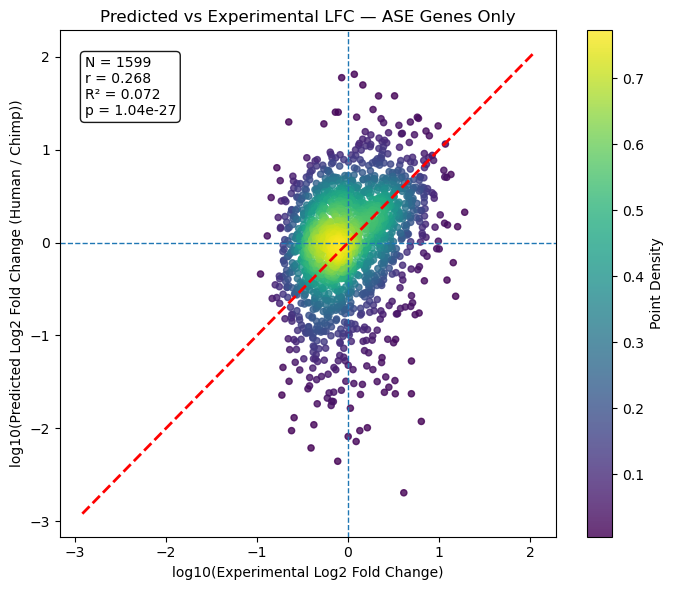

Total genes in joined dataset: 16678
ASE genes: 7575


In [14]:

# Filter to ASE genes only
ase_df = ag_preds_with_hybrids.filter(pl.col("ExpLBM_gene_ase_type") == "ASE")

# Drop NaNs
x = np.log10(ase_df['ExpLBM_LFC_human_ref'].to_numpy())
y = np.log10(ase_df['LFC'].to_numpy())

mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

# Normalization
x = x - np.mean(x)
y = y - np.mean(y)

# Density estimation
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# Sort by density so high density points plot on top
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]

# Correlation
r, p = pearsonr(x, y)
r2 = r**2

# Plot
plt.figure(figsize=(7, 6))

sc = plt.scatter(
    x, y,
    c=z,
    cmap='viridis',
    s=20,
    alpha=0.8
)

# Add x = y line
lims = [
    np.min([plt.gca().get_xlim(), plt.gca().get_ylim()]),
    np.max([plt.gca().get_xlim(), plt.gca().get_ylim()]),
]
plt.plot(lims, lims, linestyle='--', linewidth=2, color='red', label='x = y')

plt.ylabel('log10(Predicted Log2 Fold Change (Human / Chimp))')
plt.xlabel('log10(Experimental Log2 Fold Change)')
plt.title('Predicted vs Experimental LFC — ASE Genes Only')

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Point Density')

# Stats box
stats_text = (
    f'N = {len(x)}\n'
    f'r = {r:.3f}\n'
    f'R² = {r2:.3f}\n'
    f'p = {p:.2e}'
)

plt.text(
    0.05, 0.95,
    stats_text,
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9)
)

plt.axhline(0, linestyle='--', linewidth=1)
plt.axvline(0, linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

print(f"Total genes in joined dataset: {len(ag_preds_with_hybrids)}")
print(f"ASE genes: {len(ase_df)}")

## 6. Direction-of-Change Agreement

Compute the sign (±1) of both predicted and experimental LFC to obtain a discrete direction-of-change label per gene.  
Pearson correlation between these binary direction vectors quantifies how often AlphaGenome correctly predicts which species has higher expression.

In [8]:
ag_and_hybrids_with_direction = ag_preds_with_hybrids.with_columns(pl.col('LFC').sign().alias('Predicted_lfc_diirection'))
ag_and_hybrids_with_direction =ag_and_hybrids_with_direction.with_columns(pl.col('ExpLBM_LFC_human_ref').sign().alias('explbm_lfc_direction'))

In [9]:

# Drop NaNs

ag_and_hybrids_with_direction_clen_on_nulls = ag_and_hybrids_with_direction.drop_nulls(subset=['Predicted_lfc_diirection', 'explbm_lfc_direction'])
x = ag_and_hybrids_with_direction_clen_on_nulls['Predicted_lfc_diirection'].drop_nulls().to_numpy()
y = ag_and_hybrids_with_direction_clen_on_nulls['explbm_lfc_direction'].drop_nulls().to_numpy()

r, p = pearsonr(x, y)


## 7. Absolute Expression Level Correlation

Assess whether AlphaGenome predicted expression levels match experimental allele-specific TPM values from the hybrid data.  
Both axes are log₁₀-transformed and mean-centred; the red dashed identity line marks perfect agreement.

### 7.1 Human Allele

Predicted human expression (`HumanGeneExpression`) vs. experimental human allele TPM (`ExpLBM_TPM_human_allele`).

/tmp/ipykernel_2809477/4100442779.py:4: RuntimeWarning: divide by zero encountered in log10
  x = np.log10(ag_preds_with_hybrids['ExpLBM_TPM_human_allele'].to_numpy())


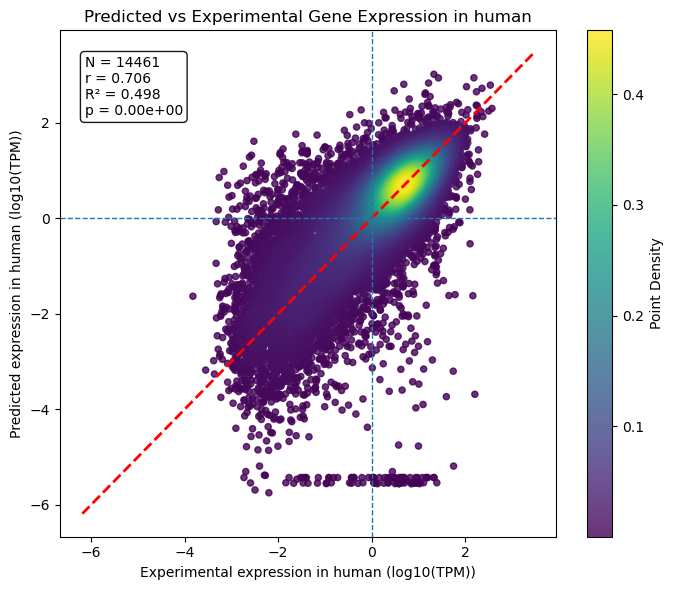

In [10]:


# Drop NaNs
y = np.log10(ag_preds_with_hybrids['HumanGeneExpression'].to_numpy()) 
# y = y - np.mean(y)
x = np.log10(ag_preds_with_hybrids['ExpLBM_TPM_human_allele'].to_numpy())
# x = x - np.mean(x)
# x = ag_preds_with_hybrids['ExpLBM_TPM_human_allele'].to_numpy()


# mask = ~np.isnan(x) & ~np.isnan(y)
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

# normalization
x = x - np.mean(x)
y = y - np.mean(y)
# Density estimation
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# Sort by density so high density points plot on top
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]

# Correlation
r, p = pearsonr(x, y)
r2 = r**2

# Plot
plt.figure(figsize=(7,6))

sc = plt.scatter(
    x, y,
    c=z,
    cmap='viridis',
    s=20,
    alpha=0.8
)

# Add x = y line
x_equal_y = [
    np.min([plt.gca().get_xlim(), plt.gca().get_ylim()]),
    np.max([plt.gca().get_xlim(), plt.gca().get_ylim()]),
]
plt.plot(x_equal_y, x_equal_y, linestyle='--', linewidth=2, color='red', label='x = y')

# # Regression line
# m, b = np.polyfit(x, y, 1)
# plt.plot(x, m*x + b, linewidth=2)

plt.ylabel('Predicted expression in human (log10(TPM))')
plt.xlabel('Experimental expression in human (log10(TPM))')
plt.title('Predicted vs Experimental Gene Expression in human')

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Point Density')

# Stats box
stats_text = (
    f'N = {len(x)}\n'
    f'r = {r:.3f}\n'
    f'R² = {r2:.3f}\n'
    f'p = {p:.2e}'
)

plt.text(
    0.05, 0.95,
    stats_text,
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9)
)

plt.axhline(0, linestyle='--', linewidth=1)
plt.axvline(0, linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

### 7.2 Chimpanzee Allele

Predicted chimp expression (`ChimpGeneExpression`) vs. experimental chimp allele TPM (`ExpLBM_TPM_chimp_allele`).

/tmp/ipykernel_2809477/1369524326.py:3: RuntimeWarning: divide by zero encountered in log10
  x = np.log10(ag_preds_with_hybrids['ExpLBM_TPM_chimp_allele'].to_numpy())


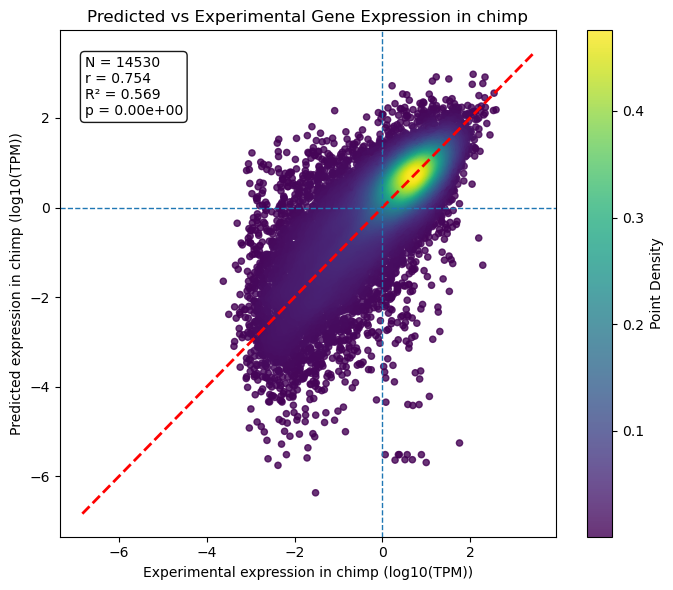

In [11]:

# Drop NaNs
y = np.log10(ag_preds_with_hybrids['ChimpGeneExpression'].to_numpy())
x = np.log10(ag_preds_with_hybrids['ExpLBM_TPM_chimp_allele'].to_numpy())

# mask = ~np.isnan(x) & ~np.isnan(y)
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

#normalization 
x = x - np.mean(x)
y = y- np.mean(y)

# Density estimation
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# Sort by density so high density points plot on top
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]

# Correlation
r, p = pearsonr(x, y)
r2 = r**2

# Plot
plt.figure(figsize=(7,6))

sc = plt.scatter(
    x, y,
    c=z,
    cmap='viridis',
    s=20,
    alpha=0.8
)
# Add x = y line
x_equal_y = [
    np.min([plt.gca().get_xlim(), plt.gca().get_ylim()]),
    np.max([plt.gca().get_xlim(), plt.gca().get_ylim()]),
]
plt.plot(x_equal_y, x_equal_y, linestyle='--', linewidth=2, color='red', label='x = y')

# # Regression line
# m, b = np.polyfit(x, y, 1)
# plt.plot(x, m*x + b, linewidth=2)

plt.ylabel('Predicted expression in chimp (log10(TPM))')
plt.xlabel('Experimental expression in chimp (log10(TPM))')
plt.title('Predicted vs Experimental Gene Expression in chimp')

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Point Density')

# Stats box
stats_text = (
    f'N = {len(x)}\n'
    f'r = {r:.3f}\n'
    f'R² = {r2:.3f}\n'
    f'p = {p:.2e}'
)

plt.text(
    0.05, 0.95,
    stats_text,
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9)
)

plt.axhline(0, linestyle='--', linewidth=1)
plt.axvline(0, linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

## 8. Side-by-Side Comparison: Human vs. Chimpanzee

Human and chimp scatter plots on a shared axis scale to allow direct visual comparison of prediction accuracy.  
Both panels use mean-centred log₁₀ TPM; axes are locked to a single global range so differences in spread are immediately visible.

/tmp/ipykernel_2809477/3160084042.py:5: RuntimeWarning: divide by zero encountered in log10
  np.log10(ag_preds_with_hybrids['ExpLBM_TPM_human_allele'].to_numpy()),
/tmp/ipykernel_2809477/3160084042.py:12: RuntimeWarning: divide by zero encountered in log10
  np.log10(ag_preds_with_hybrids['ExpLBM_TPM_chimp_allele'].to_numpy()),


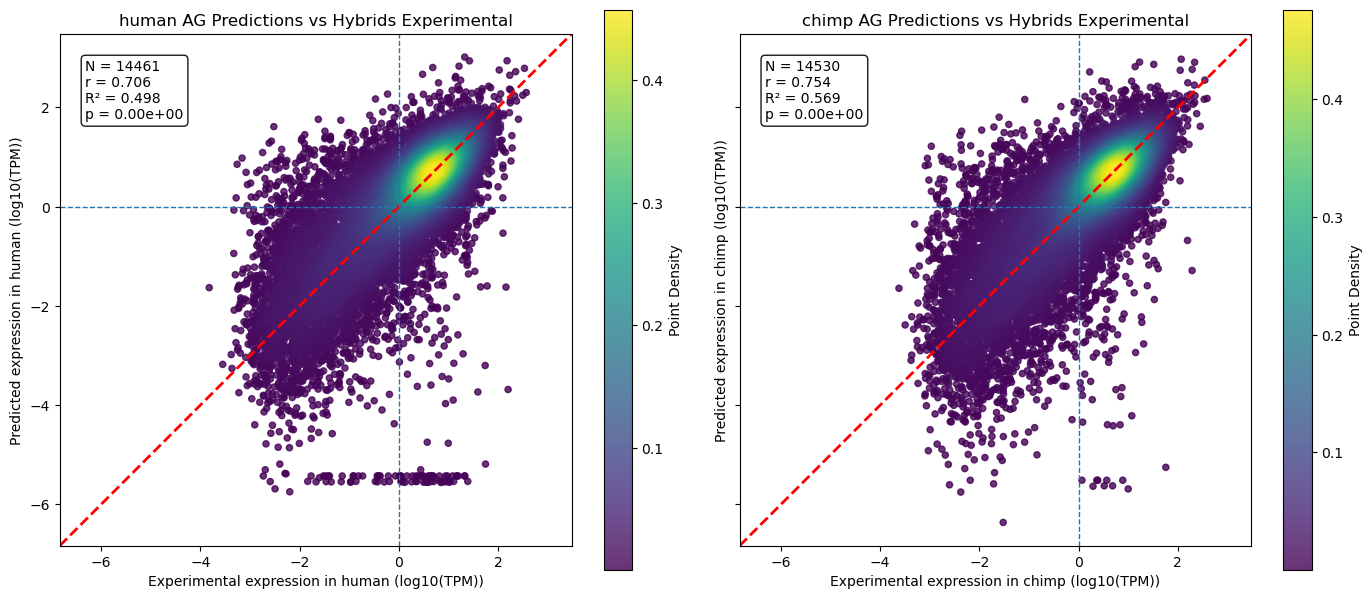

In [18]:
# Side-by-side comparison of human and chimp with identical axis scales
datasets = [
    (
        "human",
        np.log10(ag_preds_with_hybrids['ExpLBM_TPM_human_allele'].to_numpy()),
        np.log10(ag_preds_with_hybrids['HumanGeneExpression'].to_numpy()),
        'Experimental expression in human (log10(TPM))',
        'Predicted expression in human (log10(TPM))',
    ),
    (
        "chimp",
        np.log10(ag_preds_with_hybrids['ExpLBM_TPM_chimp_allele'].to_numpy()),
        np.log10(ag_preds_with_hybrids['ChimpGeneExpression'].to_numpy()),
        'Experimental expression in chimp (log10(TPM))',
        'Predicted expression in chimp (log10(TPM))',
    ),
]

prepared = []
all_values = []

for name, x_raw, y_raw, x_label, y_label in datasets:
    mask = np.isfinite(x_raw) & np.isfinite(y_raw)
    x = x_raw[mask]
    y = y_raw[mask]

    # Match previous normalization approach per species.
    x = x - np.mean(x)
    y = y - np.mean(y)

    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)

    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]

    r, p = pearsonr(x, y)
    r2 = r**2

    prepared.append((name, x, y, z, x_label, y_label, r, p, r2))
    all_values.append(x)
    all_values.append(y)

# Use one global limit so both panels have exactly the same scales.
combined = np.concatenate(all_values)
min_lim = np.min(combined)
max_lim = np.max(combined)
padding = 0.05 * (max_lim - min_lim) if max_lim > min_lim else 1.0
lims = [min_lim - padding, max_lim + padding]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, (name, x, y, z, x_label, y_label, r, p, r2) in zip(axes, prepared):
    sc = ax.scatter(
        x, y,
        c=z,
        cmap='viridis',
        s=20,
        alpha=0.8
    )
    ax.plot(lims, lims, linestyle='--', linewidth=2, color='red', label='x = y')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    # name[0] = name[0].upper() + name[1:]  # Capitalize first letter
    ax.set_title(f'{name} AG Predictions vs Hybrids Experimental')
    ax.axhline(0, linestyle='--', linewidth=1)
    ax.axvline(0, linestyle='--', linewidth=1)

    stats_text = (
        f'N = {len(x)}\n'
        f'r = {r:.3f}\n'
        f'R² = {r2:.3f}\n'
        f'p = {p:.2e}'
    )
    ax.text(
        0.05, 0.95,
        stats_text,
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9)
    )

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label('Point Density')

plt.tight_layout()
plt.show()